In [1]:
cd C:\R_projects\mothz\detectron2\custom_training

C:\R_projects\mothz\detectron2\custom_training


In [2]:
import torch, detectron2, cv2
!nvcc --version
print("\nTorch CUDA version:", torch.version.cuda)
print("\nTorch version:", torch.__version__)
print("\ndetectron2:", detectron2.__version__)
print("\ncv2 version:",cv2.__version__)


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Sep__8_19:56:38_Pacific_Daylight_Time_2023
Cuda compilation tools, release 12.3, V12.3.52
Build cuda_12.3.r12.3/compiler.33281558_0

Torch CUDA version: 12.1

Torch version: 2.1.1

detectron2: 0.6

cv2 version: 4.11.0


In [3]:
print("Python version: ")
!python --version

Python version: 
Python 3.8.20


In [4]:
# Some basic setup:
# Setup detectron2 logger
from detectron2.utils.logger import setup_logger
setup_logger()
import numpy as np
import os, json, cv2, random
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import ColorMode,GenericMask,Visualizer
from detectron2.structures.keypoints import heatmaps_to_keypoints
from matplotlib import pyplot as plt
import glob
import random
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    LVISEvaluator,
    PascalVOCDetectionEvaluator,
    SemSegEvaluator,
    DatasetEvaluator,
    inference_on_dataset,
    print_csv_format,
    verify_results,
)
import cv2 

In [5]:
# Register datasets and populate metadata
register_coco_instances("mothz_kp_train", {}, ".\keypoint\coco_kp_train.json", "C:\R_projects\mothz\coco-annotator\datasets\mothz_sample1")
register_coco_instances("mothz_kp_test", {}, ".\keypoint\coco_kp_test.json", "C:\R_projects\mothz\coco-annotator\datasets\mothz_sample1")

In [6]:
MetadataCatalog.get("mothz_kp_train")

namespace(name='mothz_kp_train',
          json_file='.\\keypoint\\coco_kp_train.json',
          image_root='C:\\R_projects\\mothz\\coco-annotator\\datasets\\mothz_sample1',
          evaluator_type='coco')

In [7]:
things = ["forewing"] 
things_color = [(255, 0, 0)]
keypoint_names = ["inner", "outer"]
keypoint_map = []

MetadataCatalog.get("mothz_kp_train").set(thing_classes=things)
MetadataCatalog.get("mothz_kp_train").set(thing_colors=things_color)
MetadataCatalog.get("mothz_kp_train").set(keypoint_names=keypoint_names)
MetadataCatalog.get("mothz_kp_train").set(keypoint_flip_map=keypoint_map)

MetadataCatalog.get("mothz_kp_test").set(thing_classes=things)
MetadataCatalog.get("mothz_kp_test").set(thing_colors=things_color)
MetadataCatalog.get("mothz_kp_test").set(keypoint_names=keypoint_names)
MetadataCatalog.get("mothz_kp_test").set(keypoint_flip_map=keypoint_map)

namespace(name='mothz_kp_test',
          json_file='.\\keypoint\\coco_kp_test.json',
          image_root='C:\\R_projects\\mothz\\coco-annotator\\datasets\\mothz_sample1',
          evaluator_type='coco',
          thing_classes=['forewing'],
          thing_colors=[(255, 0, 0)],
          keypoint_names=['inner', 'outer'],
          keypoint_flip_map=[])

In [8]:
# Define custom data maper for augmentation and custom validation data loss eval hook

from detectron2.engine.hooks import HookBase
from detectron2.evaluation import inference_context
from detectron2.utils.logger import log_every_n_seconds
from detectron2.data import DatasetMapper, build_detection_test_loader
from detectron2.engine import DefaultTrainer
import detectron2.utils.comm as comm
import torch
import time
import datetime
import logging
from detectron2.data import detection_utils as utils
import detectron2.data.transforms as T
import copy

def custom_mapper(dataset_dict):
    dataset_dict = copy.deepcopy(dataset_dict)  # it will be modified by code below
    image = utils.read_image(dataset_dict["file_name"], format="BGR")
    transform_list = [
        T.Resize((3000,2000)),
        T.RandomBrightness(0.8, 1.8),
        T.RandomContrast(0.6, 1.3),
        T.RandomSaturation(0.8, 1.4),
        T.RandomRotation(angle=[90, 90]),
        T.RandomLighting(0.7),
        T.RandomFlip(prob=0.5, horizontal=False, vertical=True),
        T.RandomFlip(prob=0.5, horizontal=True, vertical=False),
    ]
    image, transforms = T.apply_transform_gens(transform_list, image)
    dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).astype("float32"))

    annos = [
        utils.transform_instance_annotations(obj, transforms, image.shape[:2], 
                                             keypoint_hflip_indices = [0,1])
        for obj in dataset_dict.pop("annotations")
        if obj.get("iscrowd", 0) == 0
    ]
    instances = utils.annotations_to_instances(annos, image.shape[:2])
    dataset_dict["instances"] = instances
    #dataset_dict["instances"] = detectron2.data.detection_utils.filter_empty_instances(instances)
    return dataset_dict

class LossEvalHook(HookBase):
    def __init__(self, eval_period, model, data_loader):
        self._model = model
        self._period = eval_period
        self._data_loader = data_loader
    
    def _do_loss_eval(self):
        # Copying inference_on_dataset from evaluator.py
        total = len(self._data_loader)
        num_warmup = min(5, total - 1)
            
        start_time = time.perf_counter()
        total_compute_time = 0
        losses = []
        for idx, inputs in enumerate(self._data_loader):            
            if idx == num_warmup:
                start_time = time.perf_counter()
                total_compute_time = 0
            start_compute_time = time.perf_counter()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            total_compute_time += time.perf_counter() - start_compute_time
            iters_after_start = idx + 1 - num_warmup * int(idx >= num_warmup)
            seconds_per_img = total_compute_time / iters_after_start
            if idx >= num_warmup * 2 or seconds_per_img > 5:
                total_seconds_per_img = (time.perf_counter() - start_time) / iters_after_start
                eta = datetime.timedelta(seconds=int(total_seconds_per_img * (total - idx - 1)))
                log_every_n_seconds(
                    logging.INFO,
                    "Loss on Validation  done {}/{}. {:.4f} s / img. ETA={}".format(
                        idx + 1, total, seconds_per_img, str(eta)
                    ),
                    n=5,
                )
            loss_batch = self._get_loss(inputs)
            losses.append(loss_batch)
        mean_loss = np.mean(losses)
        self.trainer.storage.put_scalar('validation_loss', mean_loss)
        comm.synchronize()

        return losses
            
    def _get_loss(self, data):
        # How loss is calculated on train_loop 
        metrics_dict = self._model(data)
        metrics_dict = {
            k: v.detach().cpu().item() if isinstance(v, torch.Tensor) else float(v)
            for k, v in metrics_dict.items()
        }
        total_losses_reduced = sum(loss for loss in metrics_dict.values())
        return total_losses_reduced
        
        
    def after_step(self):
        next_iter = self.trainer.iter + 1
        is_final = next_iter == self.trainer.max_iter
        if is_final or (self._period > 0 and next_iter % self._period == 0):
            self._do_loss_eval()
        self.trainer.storage.put_scalars(timetest=12)

class CustomTrainer(DefaultTrainer):
    """
    Custom Trainer deriving from the "DefaultTrainer"

    Overloads build_hooks to add a hook to calculate loss on the test set during training.
    """

    def build_hooks(self):
        hooks = super().build_hooks()
        hooks.insert(-1, LossEvalHook(
            100, # Frequency of calculation - every 200 iterations here
            self.model,
            build_detection_test_loader(
                self.cfg,
                self.cfg.DATASETS.TEST[0],
                mapper=custom_mapper
            )
        ))

        return hooks

def filter_instance_by_classes(instances, meta_data, k):
    o = instances["instances"].to("cpu")
    things_classes = MetadataCatalog.get(meta_data).get("thing_classes")
    things_predicted = [things_classes[i] for i in o.pred_classes.tolist()]
    things_scores = o.scores.tolist()
    top_indices = []
    for thing, num_top in zip(things_classes, k):
        # Get indices of the predicted things and their scores
        indices = [i for i, name in enumerate(things_predicted) if name == thing]
        scores = [things_scores[i] for i in indices]
        
        # Get indices of the top k items based on score
        top_indices_for_thing = np.argsort(scores)[-num_top:][::-1]  # Sort and get top k
        top_indices_for_thing = [indices[i] for i in top_indices_for_thing]  # Map back to original indices
        # Store the result
        top_indices.append(top_indices_for_thing)
    top_indices = sum(top_indices, [])
    return o[top_indices]


In [9]:
# Set model configs
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("mothz_kp_train",)
cfg.DATASETS.TEST = ("mothz_kp_test", ) # Called test in detectron2, but is actually the validation data
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.DATALOADER.NUM_WORKERS = 2
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False 
cfg.TEST.EVAL_PERIOD = 0 # Turn off COCO evluator. 
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.0001  
cfg.SOLVER.MAX_ITER = 1000    
cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
cfg.SOLVER.WARMUP_ITERS = 200
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1 # Change for the number of classes
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.03 # Set to lower?
cfg.TEST.DETECTIONS_PER_IMAGE = 2 # Set higher to allow filtering by class later
cfg.SOLVER.CHECKPOINT_PERIOD = 200
cfg.MODEL.ROI_KEYPOINT_HEAD.NUM_KEYPOINTS = 2
cfg.TEST.KEYPOINT_OKS_SIGMAS = [0.1, 0.1]
cfg.INPUT.RANDOM_FLIP = "horizontal"
cfg.MODEL.MASK_ON = True
cfg.MODEL.KEYPOINT_ON = True # Keypoint detection for multiple thing classes not supported by detectron2
cfg.MODEL.ROI_KEYPOINT_HEAD.LOSS_WEIGHT = 5
cfg.MODEL.ROI_KEYPOINT_HEAD.NORMALIZE_LOSS_BY_VISIBLE_KEYPOINTS = False
cfg.OUTPUT_DIR = "./keypoint/test1"
#cfg.MODEL.BACKBONE.FREEZE_AT = 0
cfg.INPUT.MAX_SIZE_TEST = 1500
cfg.INPUT.MAX_SIZE_TRAIN = 1500
cfg.INPUT.MIN_SIZE_TEST = 1000
cfg.INPUT.MIN_SIZE_TRAIN = 1000

# cfg.MODEL.RPN.PRE_NMS_TOPK_TRAIN = 5000
#cfg.MODEL.RPN.PRE_NMS_TOPK_TEST = 3000
#cfg.MODEL.RPN.POST_NMS_TOPK_TRAIN = 2500
#cfg.MODEL.RPN.POST_NMS_TOPK_TEST = 2000
cfg.MODEL.RPN.NMS_THRESH = 0.9


os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [10]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: False
  NUM_WORKERS: 2
  REPEAT_SQRT: True
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('mothz_kp_test',)
  TRAIN: ('mothz_kp_train',)
FLOAT32_PRECISION: 
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 1500
  MAX_SIZE_TRAIN: 1500
  MIN_SIZE_TEST: 1000
  MIN_SIZE_TRAIN: 1000
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 2
    NAME: build_resnet_fpn_backbone
  DEVICE: cuda
  FPN:
    FUSE_TYPE: sum
    IN_FEAT

In [11]:
# Train model
trainer = CustomTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[01/31 17:28:02 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[01/31 17:28:03 d2.engine.train_loop]: Starting training from iteration 0


C:\Users\vsbpa\.conda\envs\mothz\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[01/31 17:28:18 d2.utils.events]:  eta: 0:09:12  iter: 19  total_loss: 12.16  loss_cls: 0.7271  loss_box_reg: 0.2795  loss_mask: 0.6912  loss_keypoint: 10.29  loss_rpn_cls: 0.06771  loss_rpn_loc: 0.01244    time: 0.5556  last_time: 0.5553  data_time: 0.1423  last_data_time: 0.0017   lr: 8.6833e-06  max_mem: 3367M
[01/31 17:28:31 d2.utils.events]:  eta: 0:09:01  iter: 39  total_loss: 12.9  loss_cls: 0.5599  loss_box_reg: 0.2979  loss_mask: 0.6698  loss_keypoint: 11.34  loss_rpn_cls: 0.06136  loss_rpn_loc: 0.00898    time: 0.5607  last_time: 0.5226  data_time: 0.0019  last_data_time: 0.0018   lr: 1.7718e-05  max_mem: 3369M
[01/31 17:28:43 d2.utils.events]:  eta: 0:08:49  iter: 59  total_loss: 14.87  loss_cls: 0.4072  loss_box_reg: 0.3765  loss_mask: 0.6268  loss_keypoint: 13.33  loss_rpn_cls: 0.04411  loss_rpn_loc: 0.009345    time: 0.5637  last_time: 0.5288  data_time: 0.0019  last_data_time: 0.0018   lr: 2.6754e-05  max_mem: 3369M
[01/31 17:28:54 d2.utils.events]:  eta: 0:08:38  iter: 

In [12]:
# Look at model performance over iterations
%load_ext tensorboard
#%reload_ext tensorboard
%tensorboard --logdir "C:/R_projects/mothz/detectron2/custom_training/keypoint/test1"

### Go to directroy to delete temp file if TensorBoard fails to launch
# !del /S C:\Users\vsbpa\AppData\Local\Temp\.tensorboard-info

In [13]:
# Load fitted model as predictor
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_0000599.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.1  # set to 0.3 for now, but actually filtered to 0.7 in R
predictor = DefaultPredictor(cfg)

[02/03 10:32:45 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./keypoint/test1\model_0000599.pth ...


In [41]:
def draw_kp_mask(instances, Visualizer, radius = 20): 
    kp_l = instances.pred_keypoints.tolist()
    mask_l = np.asarray(instances.pred_masks)
    for i in range(len(kp_l)):
        try: out = Visualizer.draw_circle(kp_l[i][0][:2:], "green", radius = radius)
        except: print("inner point not detected") 
        try: out = Visualizer.draw_circle(kp_l[i][1][:2:], "red", radius = radius)
        except: print("outer point not detected") 
        try: out = Visualizer.draw_soft_mask(mask_l[i,:,:], "blue",alpha = 0.3)
        except: print("mask not detected") 
    return out
        
    

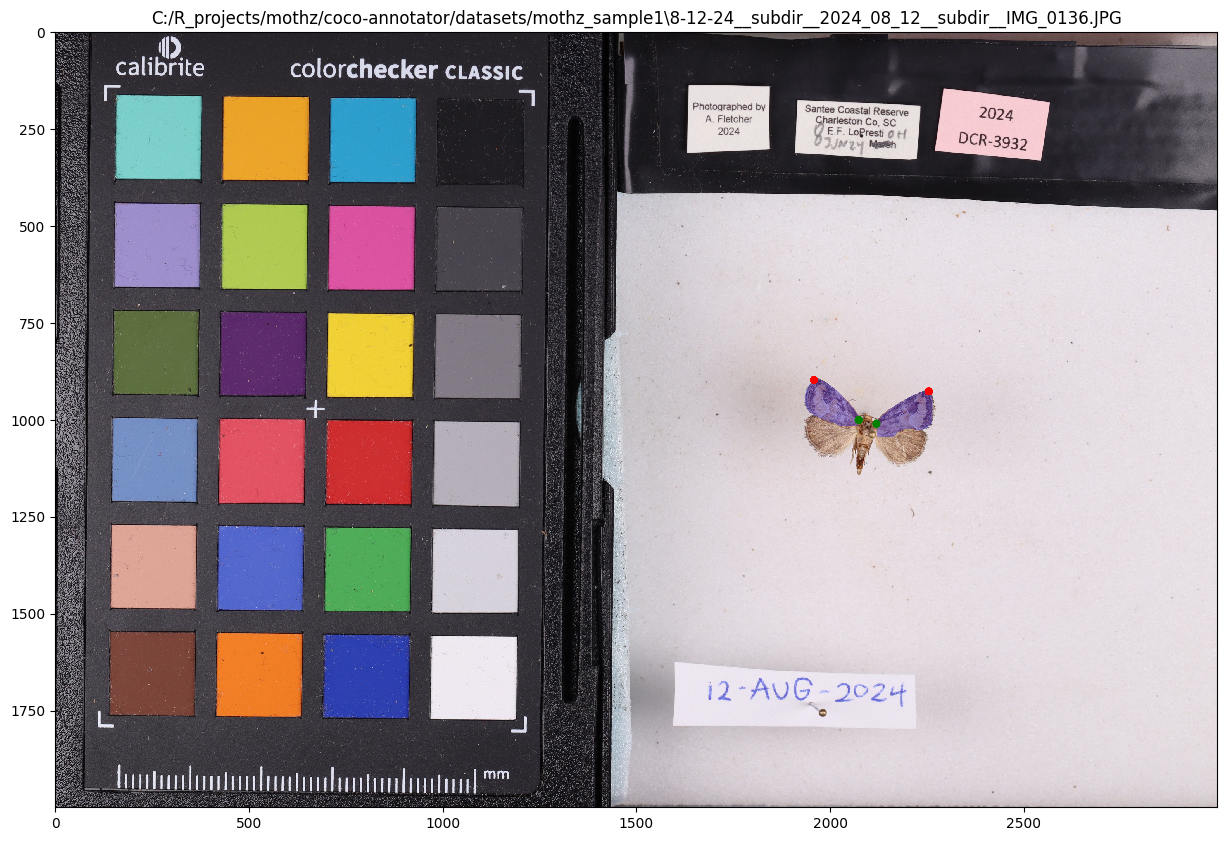

In [51]:
%matplotlib inline 

f = glob.glob("C:/R_projects/mothz/coco-annotator/datasets/mothz_sample1/*.JPG")
fi = random.choice(f)
#fi = f[0]
im = cv2.imread(fi)
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v = Visualizer(im[:, :, 0:3][:,:,::-1],
                   metadata=MetadataCatalog.get("mothz_kp_train"), 
                   scale=0.5, 
               instance_mode=ColorMode.IMAGE_BW
)
outputs = filter_instance_by_classes(outputs, "mothz_kp_test",[2]) # max detection: ['forewing']
#out = v.draw_instance_predictions(outputs, )
out = draw_kp_mask(outputs, v)

plt.figure(figsize = (15,15))
plt.imshow(out.get_image()[:,:,0:3], interpolation='nearest')
plt.title(fi)
plt.show()

In [86]:
# For writing predictions
import csv
from datetime import datetime

# Function for writing csv
def write_csv(path, df):
    keys = df[0].keys()
    with open(path, "w", newline = "") as output_file: 
        dict_writer = csv.DictWriter(output_file, keys)
        dict_writer.writeheader()
        dict_writer.writerows(df)

def mask2polygon(mask, epsilon_wt = 0.01): 
  cont, _ = cv2.findContours(mask.astype('uint8'),cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE) 
  # format contour list as COCO
  polygon = []
  for contour in cont:
      epsilon = epsilon_wt * cv2.arcLength(contour, True)  # You can adjust epsilon based on your requirements
      approx = cv2.approxPolyDP(contour, epsilon, True)
      contour = np.flip(approx, axis=1)
      segmentation = contour.ravel().tolist()
      polygon.append(segmentation)
                    
  return polygon

def gather_image_meta(fi, instances, inference_info): 
    data = {}
    data["file_name"] = fi
    data["image_size"] = list(instances.image_size)
    data["inference_info"] = inference_info
    return data

def gather_instance_pred(fi, instances, meta): 
    dataset = []
    pred_classes = instances.pred_classes.tolist()
    classes_label = MetadataCatalog.get(meta).get("thing_classes")
    pred_class_score = instances.scores.tolist()
    pred_keypoints = instances.pred_keypoints.tolist()
    pred_bbox = instances.pred_boxes.tensor.tolist()
    pred_masks = instances.pred_masks.numpy()
    
    for i in range(len(instances)):
        data = {}
        data["file_name"] = fi
        data["thing_class"] = classes_label[pred_classes[i]]
        data["score"] = pred_class_score[i]
        data["keypoints"] = np.array(pred_keypoints[i]).ravel().tolist()
        data["bbox"] = pred_bbox[i]
        data["polygon"] = mask2polygon(pred_masks[i], 0.0001)
        dataset.append(data)
        
    return dataset


# For performing model inference on all images in a subdirectory corresponding to the supplied rep_ID in a root directory
def img_inference(predictor, root_path, inference_info, meta):
    meta_data_out = []
    instance_data_out = []
    f = glob.glob(os.path.join(root_path,"*.JPG"))
    tot = len(f)
    for i in range(tot):
        print(f"{i+1} of {tot}", end = "\r")
        fi = f[i]
        inst = predictor(cv2.imread(fi))
        inst = filter_instance_by_classes(inst, meta, [2])
        meta_data = gather_image_meta(fi, inst, inference_info)
        instance_data = gather_instance_pred(fi, inst, meta)
        meta_data_out.append(meta_data)
        instance_data_out = instance_data_out + instance_data
    
    return meta_data_out, instance_data_out

# Wrapper for writing model inference on all images in a subdirectory of the root directory 
def write_img_inference(predictor, write_path, name, read_path, model_ver, meta):
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    inference_info = model_ver + "__" + now
    df_meta, df_instance = img_inference(predictor, read_path, inference_info, meta)
    write_csv(os.path.join(write_path, name + "_inference_keypoint.csv"), df_instance)
    write_csv(os.path.join(write_path, name + "_image_meta_keypoint.csv"), df_meta)
    

In [88]:
# Perform inference on the training dataset, saving both groundtruths and predictions
write_img_inference(
    predictor, 
    write_path = "C:/R_projects/mothz/",
    name = "test_auto_annotation",
    read_path = "C:/R_projects/mothz/coco-annotator/datasets/mothz_sample1/", 
    model_ver = "modelv0.1",
    meta = "mothz_kp_train"
    )

In [81]:
a,b = img_inference(predictor,  "C:/R_projects/mothz/test/", "", "mothz_kp_train")